In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
# All variables are initialized on CPU (default)
initializer = tf.initializers.GlorotUniform()

W1 = tf.Variable(initializer([784, 128]), trainable=True)
b1 = tf.Variable(tf.zeros([128]), trainable=True)
W2 = tf.Variable(initializer([128, 64]), trainable=True)
b2 = tf.Variable(tf.zeros([64]), trainable=True)
W3 = tf.Variable(initializer([64, 32]), trainable=True)
b3 = tf.Variable(tf.zeros([32]), trainable=True)

W4 = tf.Variable(initializer([32, 10]), trainable=True)
b4 = tf.Variable(tf.zeros([10]), trainable=True)

In [ ]:
learning_rate = 0.001
batch_size = 64
epochs = 5

# Activation
def relu(x):
    return tf.nn.relu(x)

# Forward pass
def forward(x, W1, b1, W2, b2, W3, b3, W4, b4):
    z1 = tf.matmul(x, W1) + b1
    a1 = relu(z1)
    z2 = tf.matmul(a1, W2) + b2
    a2 = relu(z2)
    z3 = tf.matmul(a2, W3) + b3
    a3 = relu(z3)
    z4 = tf.matmul(a3, W4) + b4
    return tf.nn.softmax(z4)

# Loss
def loss_fn(y_pred, y_true):
    return tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_true, y_pred))

# Optimizer
optimizer = tf.optimizers.Adam(learning_rate)

# @tf.function can stay, but it's easier to debug without it
def train_step(x_batch, y_batch):
    # Move batch + weights to GPU
    with tf.device('/GPU:0'):
        x_batch = tf.convert_to_tensor(x_batch)
        y_batch = tf.convert_to_tensor(y_batch)

        with tf.GradientTape() as tape:
            y_pred = forward(x_batch, W1, b1, W2, b2, W3, b3, W4, b4)
            loss = loss_fn(y_pred, y_batch)

        grads = tape.gradient(loss, [W1, b1, W2, b2, W3, b3, W4, b4])
        optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2, W3, b3, W4, b4]))
    return loss

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(batch_size)

# Lists for custom training loop metrics
custom_losses = []
custom_accuracies = []

# Custom training loop
for epoch in range(epochs):
    epoch_loss = 0.0
    correct = 0
    total = 0
    for step, (x_batch, y_batch) in enumerate(train_dataset):
        loss = train_step(x_batch, y_batch)
        epoch_loss += loss.numpy()

        with tf.device('/GPU:0'):
            logits = forward(tf.convert_to_tensor(x_batch), W1, b1, W2, b2, W3, b3, W4, b4)
            predicted_labels = tf.argmax(logits, axis=1)
            true_labels = tf.argmax(y_batch, axis=1)
            correct += tf.reduce_sum(tf.cast(predicted_labels == true_labels, tf.int32)).numpy()
            total += x_batch.shape[0]

    avg_loss = epoch_loss / (step + 1)
    accuracy = correct / total * 100

    custom_losses.append(avg_loss)
    custom_accuracies.append(accuracy)

    print(f"[Custom Loop] Epoch {epoch+1}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")


[Custom Loop] Epoch 1, Loss: 0.3207, Accuracy: 91.47%
[Custom Loop] Epoch 2, Loss: 0.1308, Accuracy: 96.64%
[Custom Loop] Epoch 3, Loss: 0.0914, Accuracy: 97.78%
[Custom Loop] Epoch 4, Loss: 0.0665, Accuracy: 98.52%
[Custom Loop] Epoch 5, Loss: 0.0487, Accuracy: 99.08%


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8285 - loss: 0.5834 - val_accuracy: 0.9575 - val_loss: 0.1408
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9620 - loss: 0.1319 - val_accuracy: 0.9728 - val_loss: 0.0927
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9730 - loss: 0.0886 - val_accuracy: 0.9755 - val_loss: 0.0834
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9795 - loss: 0.0653 - val_accuracy: 0.9767 - val_loss: 0.0821
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9851 - loss: 0.0462 - val_accuracy: 0.9740 - val_loss: 0.0885


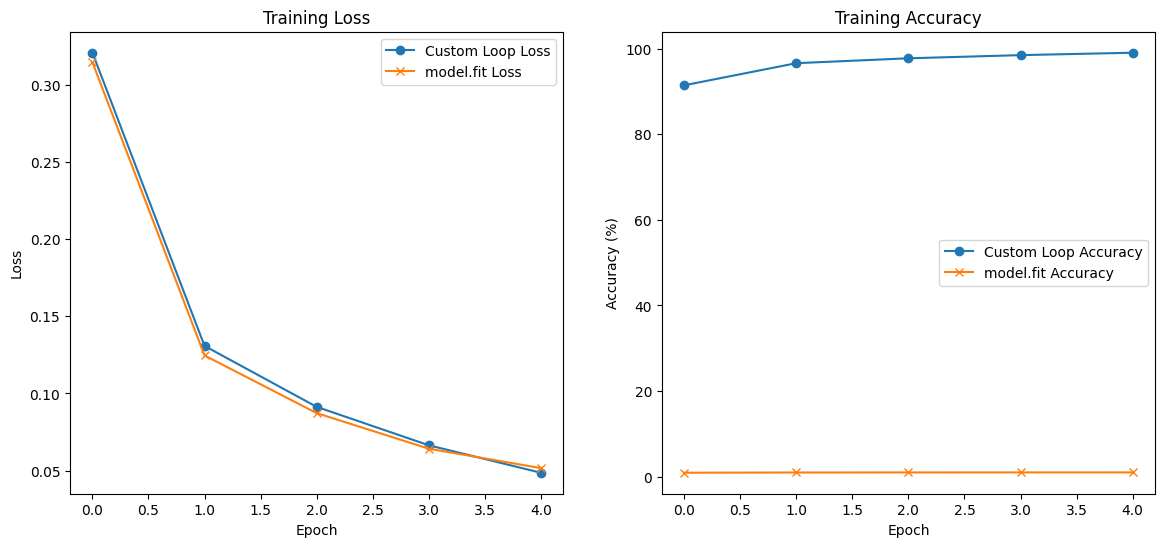

In [ ]:
# Now build and train the Keras Sequential model
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

# Plot the comparison

plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plt.plot(custom_losses, 'o-', label='Custom Loop Loss')
plt.plot(history.history['loss'], 'x-', label='model.fit Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(custom_accuracies, 'o-', label='Custom Loop Accuracy')
plt.plot(history.history['accuracy'], 'x-', label='model.fit Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()